# Week 2: Factor Foundations — Value and Momentum

Research question: *From July 2021 to August 2026, among my 50 large-cap stocks, which earns the higher average monthly return: high or low book-to-market stocks (sorted annually each June), and past winners or past losers (12-1 momentum, sorted monthly), using equal-weight quintile portfolios?*

Design note and look-ahead checklist: see Task 1 (Google Doc).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
from datetime import date

sys.path.append("../../src")
from data_utils import (load_ohlcv, check_missing_prices, check_duplicates, check_zero_prices,
                        check_extreme_returns, check_invalid_dates,
                        load_book_equity, get_shares_history, get_splits_history)
from factor_utils import get_ranking_dates, value_signal, detect_shares_split_adjusted

RAW = "../../data/raw"
SIGNALS = "../../data/signals"
os.makedirs(RAW, exist_ok=True)
os.makedirs(SIGNALS, exist_ok=True)

tickers = [
    "NVDA", "META", "GOOGL", "MSFT", "TSLA", "ORCL", "AMD", "INTC", "SMCI", "MU",
    "RKLB", "WDC", "STX", "CRWD", "PLTR", "AAPL", "AMZN", "AVGO", "CSCO", "ADBE",
    "CRM", "NFLX", "QCOM", "TXN", "TSM", "JPM", "BAC", "WFC", "V", "MA",
    "JNJ", "PFE", "MRK", "UNH", "ABT", "PG", "KO", "PEP", "WMT", "COST",
    "HD", "NKE", "MCD", "ASML", "XOM", "CVX", "HON", "CAT", "GE", "TMO",
]

## Task 2: Value Signal Construction

### 2.1 Prices from 2020
The June 2021 sort needs December 2020 prices. Downloaded once, then loaded from `data/raw/`.

In [2]:
path = f"{RAW}/prices_2020.csv"
if os.path.exists(path):
    prices = pd.read_csv(path, parse_dates=["date"])
else:
    prices = load_ohlcv(tickers, start="2020-01-01", end=str(date.today()))
    prices["date"] = pd.to_datetime(prices["date"])
    if prices["date"].dt.tz is not None:
        prices["date"] = prices["date"].dt.tz_localize(None)
    prices.to_csv(path, index=False)

prices.groupby("ticker")["date"].min().sort_values().tail()   # latest first dates (PLTR, RKLB)

ticker
JPM    2020-01-02
KO     2020-01-02
XOM    2020-01-02
PLTR   2020-09-30
RKLB   2020-11-24
Name: date, dtype: datetime64[us]

### 2.2 Data quality checks (reused from Week 1)

In [3]:
print("Missing prices:", len(check_missing_prices(prices)))
print("Duplicates:", len(check_duplicates(prices)))
print("Zero prices:", len(check_zero_prices(prices)))
print("Invalid dates:", len(check_invalid_dates(prices, "2020-01-01", str(date.today()))))
check_extreme_returns(prices)[["date", "ticker", "daily_return"]]

Missing prices: 0
Duplicates: 0
Zero prices: 0
Invalid dates: 0


,date,ticker,daily_return


### 2.3 Book equity from SEC EDGAR
As originally reported in each 10-K, with the filing date. Downloaded from each company's full SEC data file.

**One-time setup:** the SEC requires a name and email with each request. Create a file called `.env` in the repo root (next to `README`/`src/`) containing one line:
```
SEC_USER_AGENT=Your Name you@example.com
```
`.env` is in `.gitignore`, so it is never pushed.

In [4]:
path = f"{RAW}/book_equity.csv"
if os.path.exists(path):
    book_equity = pd.read_csv(path, parse_dates=["fy_end", "be_filed"])
else:
    book_equity = load_book_equity(tickers)
    book_equity.to_csv(path, index=False)

# Force date types (an empty SEC result can turn these into plain objects)
book_equity["fy_end"] = pd.to_datetime(book_equity["fy_end"])
book_equity["be_filed"] = pd.to_datetime(book_equity["be_filed"])

be_hist = {tk: g.drop(columns="ticker").reset_index(drop=True) for tk, g in book_equity.groupby("ticker")}
print("Tickers with book equity:", len(be_hist))
print("No book equity returned:", sorted(set(tickers) - set(be_hist) - {"TSM", "ASML"}))

# Latest fiscal year available per ticker - anything stuck before 2025 is a data gap
latest = book_equity.groupby("ticker")["fy_end"].max().sort_values()
print("Latest FY before 2025 (data gaps):", latest[latest < "2025-01-01"].dt.date.to_dict())
book_equity[book_equity["ticker"] == "MCD"].tail(6)     # should be negative

Tickers with book equity: 48
No book equity returned: []
Latest FY before 2025 (data gaps): {}


,fy_end,book_equity,be_filed,be_concept,ticker
766,2020-12-31,-7824900000,2021-02-23,StockholdersEquity,MCD
767,2021-12-31,-4601000000,2022-02-24,StockholdersEquity,MCD
768,2022-12-31,-6003400000,2023-02-24,StockholdersEquity,MCD
769,2023-12-31,-4706700000,2024-02-22,StockholdersEquity,MCD
770,2024-12-31,-3797000000,2025-02-25,StockholdersEquity,MCD
771,2025-12-31,-1791000000,2026-02-24,StockholdersEquity,MCD


**Diagnose book equity gaps.** For any ticker still missing or stopping before 2025, list every equity label it has used in 10-Ks since 2019. If a sensible label (total equity of the company's shareholders) shows up that isn't in `EQUITY_CONCEPTS`, add it to that list in `data_utils.py`; if the ticker's SEC ID has no history, add the right ID to `CIK_OVERRIDES`. Then delete `data/raw/book_equity.csv` and rerun 2.3.

In [5]:
from data_utils import get_cik_map, find_equity_concepts, CIK_OVERRIDES
cik_map = get_cik_map()
latest = book_equity.groupby("ticker")["fy_end"].max()
gaps = sorted((set(tickers) - set(be_hist) - {"TSM", "ASML"}) | set(latest[latest < "2025-01-01"].index))
print("Tickers to diagnose:", gaps)
for tk in gaps:
    for cik in (CIK_OVERRIDES.get(tk) or [cik_map[tk]]):
        print(f"\n===== {tk} (CIK {cik}) =====")
        display(find_equity_concepts(cik).head(8))

Tickers to diagnose: []


### 2.4 Shares outstanding and split history (yfinance)

In [6]:
sh_path, sp_path = f"{RAW}/shares.csv", f"{RAW}/splits.csv"
if os.path.exists(sh_path) and os.path.exists(sp_path):
    sh = pd.read_csv(sh_path, parse_dates=["date"])
    shares_hist = {tk: g.set_index("date")["shares"] for tk, g in sh.groupby("ticker")}
    sp = pd.read_csv(sp_path, parse_dates=["date"])
    sp["date"] = sp["date"].dt.normalize()          # yfinance stamps splits at 09:30; keep the date
    splits_hist = {tk: g.set_index("date")["ratio"] for tk, g in sp.groupby("ticker")}
else:
    shares_hist = get_shares_history(tickers, start="2020-06-01")
    splits_hist = get_splits_history(tickers)
    pd.concat(shares_hist, names=["ticker", "date"]).rename("shares").reset_index().to_csv(sh_path, index=False)
    pd.concat({k: v for k, v in splits_hist.items() if v is not None and len(v)},
              names=["ticker", "date"]).rename("ratio").reset_index().to_csv(sp_path, index=False)

print("Tickers with shares data:", len(shares_hist))

Tickers with shares data: 50


**Are yfinance share counts split-adjusted?** Detected automatically: for each real stock split (e.g. NVDA 10:1 in 2024, GOOGL/AMZN 20:1 in 2022), compare the median share count over the year before vs the year after. A jump by the split ratio means yfinance reports actual historical counts, so the split-adjusted `close` is converted back to the actual traded price to match. (Small yfinance "splits" like GE 1.28 or PFE 1.05 are spin-offs and are skipped.)

In [7]:
SHARES_SPLIT_ADJUSTED, split_evidence = detect_shares_split_adjusted(shares_hist, splits_hist)
if SHARES_SPLIT_ADJUSTED is None:
    raise ValueError("No split found inside the share history - can't tell how shares are reported. Check manually.")
print("Share counts split-adjusted?", SHARES_SPLIT_ADJUSTED)
split_evidence

Share counts split-adjusted? False


,ticker,split_date,split_ratio,median_before,median_after,observed_ratio,looks_adjusted
0,AAPL,2020-08-31,4.000,4.275630e+09,1.678810e+10,3.93,False
1,AMZN,2022-06-06,20.000,5.088440e+08,1.024730e+10,20.14,False
2,AVGO,2024-07-15,10.000,4.634210e+08,4.687360e+09,10.11,False
3,GE,2021-08-02,0.125,8.773290e+09,1.099320e+09,0.13,False
4,GOOGL,2022-07-18,20.000,6.644470e+08,1.286740e+10,19.37,False
5,NFLX,2025-11-17,10.000,4.255710e+08,4.222162e+09,9.92,False
6,NVDA,2024-06-10,10.000,2.470565e+09,2.453000e+10,9.93,False
7,SMCI,2024-10-01,10.000,5.855040e+07,5.967890e+08,10.19,False
8,TSLA,2020-08-31,5.000,1.863620e+08,9.615920e+08,5.16,False
9,TSLA,2022-08-25,3.000,1.033510e+09,3.169405e+09,3.07,False


### 2.5 Ranking dates: last trading day of each June, 2021–2026

In [8]:
ranking_dates = get_ranking_dates(prices, month=6, start="2021-01-01")
[d.date() for d in ranking_dates]

[datetime.date(2021, 6, 30),
 datetime.date(2022, 6, 30),
 datetime.date(2023, 6, 30),
 datetime.date(2024, 6, 28),
 datetime.date(2025, 6, 30),
 datetime.date(2026, 6, 30)]

### 2.6 Test one date against the Task 1 worked example (t = 2023-06-30)
Expected: `fy_end` JPM 2022-12-31, AAPL 2022-09-24, MSFT 2022-06-30, NVDA 2022-01-30; `me_date` 2022-12-30; every `be_filed` before 2023-06-30; JPM flagged "bank".

In [9]:
v23 = value_signal(pd.Timestamp("2023-06-30"), tickers, be_hist, shares_hist, splits_hist, prices,
                   shares_split_adjusted=SHARES_SPLIT_ADJUSTED)
v23.set_index("ticker").loc[["JPM", "AAPL", "MSFT", "NVDA"],
    ["fy_end", "be_filed", "me_date", "price", "book_equity", "market_cap", "bm", "excluded_reason"]]

,fy_end,be_filed,me_date,price,book_equity,market_cap,bm,excluded_reason
ticker,,,,,,,,
JPM,2022-12-31,2023-02-21,2022-12-30,134.100006,2.923320e+11,3.933421e+11,0.743200,bank
AAPL,2022-09-24,2022-10-28,2022-12-30,129.929993,5.067200e+10,2.066939e+12,0.024515,NaN
MSFT,2022-06-30,2022-07-28,2022-12-30,239.820007,1.665420e+11,1.787731e+12,0.093158,NaN
NVDA,2022-01-30,2022-03-18,2022-12-30,146.140003,2.661200e+10,3.641809e+11,0.073074,NaN


**Market cap sanity check** (end of 2022, roughly): NVDA ≈ $0.36T, AAPL ≈ $2.1T, MSFT ≈ $1.8T, GOOGL ≈ $1.1T, META ≈ $0.3T. If GOOGL or META is far too low, yfinance is counting only one share class.

In [10]:
(v23.set_index("ticker").loc[["NVDA", "AAPL", "MSFT", "GOOGL", "META"], "market_cap"] / 1e12).round(2)

ticker
NVDA     0.36
AAPL     2.07
MSFT     1.79
GOOGL    1.14
META     0.32
Name: market_cap, dtype: float64

### 2.7 All ranking dates → save the value signal table

In [11]:
value_signals = pd.concat(
    [value_signal(t, tickers, be_hist, shares_hist, splits_hist, prices,
                  shares_split_adjusted=SHARES_SPLIT_ADJUSTED) for t in ranking_dates],
    ignore_index=True)
value_signals.to_csv(f"{SIGNALS}/value_signals.csv", index=False)
value_signals.head()

,rebalance_date,ticker,me_date,fy_end,be_filed,book_equity,shares,shares_date,price,shares_age_days,market_cap,bm,excluded_reason,bm_w,rank_pct
0,2021-06-30,NVDA,2020-12-31,2020-01-26,2020-02-20,1.220400e+10,6.190000e+08,2020-11-26,522.200012,35.0,3.232418e+11,0.037755,NaN,0.037755,0.195122
1,2021-06-30,META,2020-12-31,2020-12-31,2021-01-28,1.282900e+11,NaN,NaT,273.160004,NaN,NaN,NaN,missing price/shares,NaN,NaN
2,2021-06-30,GOOGL,2020-12-31,2020-12-31,2021-02-03,2.225440e+11,6.770480e+08,2020-12-31,1752.640076,0.0,1.186621e+12,0.187544,NaN,0.187544,0.756098
3,2021-06-30,MSFT,2020-12-31,2020-06-30,2020-07-30,1.183040e+11,7.560500e+09,2020-11-26,222.419998,35.0,1.681606e+12,0.070352,NaN,0.070352,0.390244
4,2021-06-30,TSLA,2020-12-31,2020-12-31,2021-02-08,2.222500e+10,9.479010e+08,2020-11-26,705.669983,35.0,6.689053e+11,0.033226,NaN,0.033226,0.097561


### 2.8 Sanity checks
**Exclusions per date.** Expect 3 banks + 2 foreign every year; MCD negative every year; STX negative from 2024; ORCL and HD negative in 2023; RKLB missing in 2021.

In [12]:
value_signals.groupby(["rebalance_date", "excluded_reason"], dropna=False).size().unstack(fill_value=0)

excluded_reason,bank,foreign currency,missing price/shares,negative book equity,NaN
rebalance_date,,,,,
2021-06-30,3,2,2,2,41
2022-06-30,3,2,1,1,43
2023-06-30,3,2,0,3,42
2024-06-28,3,2,0,2,43
2025-06-30,3,2,0,2,43
2026-06-30,3,2,0,2,43


In [13]:
value_signals[value_signals["excluded_reason"].notna() & ~value_signals["ticker"].isin(["JPM","BAC","WFC","TSM","ASML"])] \
    [["rebalance_date", "ticker", "excluded_reason"]].sort_values(["rebalance_date", "ticker"])

,rebalance_date,ticker,excluded_reason
40,2021-06-30,HD,negative book equity
42,2021-06-30,MCD,negative book equity
1,2021-06-30,META,missing price/shares
10,2021-06-30,RKLB,missing price/shares
92,2022-06-30,MCD,negative book equity
51,2022-06-30,META,missing price/shares
140,2023-06-30,HD,negative book equity
142,2023-06-30,MCD,negative book equity
105,2023-06-30,ORCL,negative book equity
192,2024-06-28,MCD,negative book equity


**Direction check.** Cheap (high B/M) should look like energy, pharma, older industrials; expensive should look like high-growth tech.

In [14]:
for t, g in value_signals.dropna(subset=["rank_pct"]).groupby("rebalance_date"):
    g = g.sort_values("rank_pct")
    print(t.date(), "| expensive:", list(g["ticker"].head(5)), "| cheap:", list(g["ticker"].tail(5)))

2021-06-30 | expensive: ['MA', 'AAPL', 'CRWD', 'TSLA', 'PLTR'] | cheap: ['MU', 'WDC', 'SMCI', 'XOM', 'CVX']
2022-06-30 | expensive: ['HD', 'MA', 'CRWD', 'AAPL', 'ORCL'] | cheap: ['INTC', 'SMCI', 'WDC', 'XOM', 'CVX']
2023-06-30 | expensive: ['AAPL', 'STX', 'MA', 'CRWD', 'PEP'] | cheap: ['CVX', 'AMD', 'INTC', 'WDC', 'MU']
2024-06-28 | expensive: ['MA', 'ORCL', 'HD', 'NVDA', 'AAPL'] | cheap: ['INTC', 'XOM', 'CVX', 'WDC', 'PFE']
2025-06-30 | expensive: ['NVDA', 'MA', 'HD', 'AAPL', 'ORCL'] | cheap: ['WDC', 'XOM', 'PFE', 'CVX', 'INTC']
2026-06-30 | expensive: ['NVDA', 'MA', 'PLTR', 'AAPL', 'HD'] | cheap: ['SMCI', 'XOM', 'INTC', 'CVX', 'PFE']


**Winsorizing.** Compare raw vs winsorized B/M per date.

In [15]:
value_signals.groupby("rebalance_date")[["bm", "bm_w"]].describe().round(3)

bm                                                   bm_w  \
               count   mean    std    min    25%    50%    75%    max count   
rebalance_date                                                                
2021-06-30      46.0  0.236  0.316 -0.049  0.053  0.120  0.204  1.482  41.0   
2022-06-30      47.0  0.195  0.226 -0.023  0.052  0.117  0.199  0.957  43.0   
2023-06-30      48.0  0.276  0.310 -0.031  0.088  0.164  0.381  1.219  42.0   
2024-06-28      48.0  0.215  0.251 -0.067  0.078  0.132  0.219  1.095  43.0   
2025-06-30      48.0  0.212  0.253 -0.082  0.061  0.124  0.245  1.148  43.0   
2026-06-30      48.0  0.180  0.193 -0.008  0.056  0.106  0.210  0.744  43.0   

                                                                 
                 mean    std    min    25%    50%    75%    max  
rebalance_date                                                   
2021-06-30      0.178  0.182  0.029  0.055  0.118  0.188  0.650  
2022-06-30      0.155  0.154  0.021  0.052  0.091  0.165  0.523  
2023-06-30      0.239  0.226  0.025  0.094  0.164  0.331  0.896  
2024-06-28      0.175  0.154  0.017  0.079  0.130  0.204  0.544  
2025-06-30      0.175  0.171  0.014  0.063  0.124  0.208  0.584  
2026-06-30      0.159  0.157  0.018  0.057  0.106  0.175  0.597

In [16]:
ranked = value_signals[value_signals["excluded_reason"].isna()]
summary = ranked.groupby("rebalance_date").apply(lambda g: pd.Series({
    "n_ranked":        len(g),
    "p5_cutoff":       g["bm"].quantile(0.05),
    "p95_cutoff":      g["bm"].quantile(0.95),
    "n_capped":        (g["bm"].round(6) != g["bm_w"].round(6)).sum(),
    "min_before":      g["bm"].min(),   "min_after": g["bm_w"].min(),
    "median_before":   g["bm"].median(), "median_after": g["bm_w"].median(),
    "max_before":      g["bm"].max(),   "max_after": g["bm_w"].max(),
    "order_preserved": g.sort_values("bm")["bm_w"].is_monotonic_increasing,
}))
summary.round(3)

,n_ranked,p5_cutoff,p95_cutoff,n_capped,min_before,min_after,median_before,median_after,max_before,max_after,order_preserved
rebalance_date,,,,,,,,,,,
2021-06-30,41,0.029,0.650,4,0.016,0.029,0.118,0.118,0.902,0.650,True
2022-06-30,43,0.021,0.523,6,0.008,0.021,0.091,0.091,0.647,0.523,True
2023-06-30,42,0.025,0.896,6,0.010,0.025,0.164,0.164,1.219,0.896,True
2024-06-28,43,0.017,0.544,6,0.004,0.017,0.130,0.130,0.639,0.544,True
2025-06-30,43,0.014,0.584,6,0.003,0.014,0.124,0.124,1.148,0.584,True
2026-06-30,43,0.018,0.597,6,0.015,0.018,0.106,0.106,0.649,0.597,True


### 2.9 Value signal: notes

- **Score:** B/M = book equity ÷ market cap. Book equity comes from each firm's fiscal year ending in calendar year t−1 (52/53-week years ending in the first two weeks of January, e.g. JNJ's FY2022 ending 2023-01-01, count as the previous year), as originally reported in its 10-K (SEC EDGAR full company data files), and is used only if filed on or before t. Market cap = shares outstanding × actual traded price on the last trading day of December t−1.
- **Price and shares on the same basis:** yfinance share counts are actual historical counts (confirmed: all 11 real splits in the data show the count jumping by the split ratio). yfinance `close` is split-adjusted backwards, so it is converted back to the actual traded price using split history. `adj_close` is not used because it also removes dividends.
- **Ranking dates:** last trading day of June, 2021–2026. `rank_pct` runs from near 0 (most expensive) to 1 (cheapest) within each date.
- **Exclusions (flagged, not ranked):** per date, 41–43 of 50 stocks are ranked. Excluded every year: JPM, BAC, WFC (banks; B/M not comparable) and TSM, ASML (non-USD reporting). Negative book equity: MCD (all years), HD (2021, 2023), ORCL (2023), STX (2024–2026). Missing data: META (2021–2022; yfinance share history starts at the FB→META ticker change in June 2022) and RKLB (2021; not yet listed).
- **Stale share counts:** yfinance share history has gaps (e.g. NVDA has no observations from July 2021 to April 2023). Share counts change slowly, so counts up to 18 months old are used, with any split in between applied; older counts are flagged.
- **SEC data notes:** book equity uses the parent-company label (`StockholdersEquity`) where available and total equity including minority interest otherwise (e.g. Visa, JNJ). XOM's current SEC ID has no history, so its original ID (34088) is also used.
- **Winsorizing:** B/M clipped at the 5th/95th percentile within each date; with ~43 stocks, 1%/99% would clip nothing. For a single metric this does not change rank order; it matters if B/M is later combined with other metrics.
- **Checks passed:** the June 2023 worked example matches the Task 1 design; end-2022 market caps match reported values (AAPL $2.07T, MSFT $1.79T, GOOGL $1.15T, NVDA $0.36T, META $0.32T), so share counts cover all share classes for GOOGL and META.
- **Limitations:** yfinance share counts are noisy and gappy; ~43 stocks gives ~8–9 per quintile; the universe was chosen with hindsight.
- **Proxy:** none used. All scored stocks use reported fundamentals.

## Task 3: Momentum Signal Construction

**12-1 momentum** at month-end t = the stock's return from the end of month t−12 to the end of month t−1:

  mom = adj_close(end of t−1) ÷ adj_close(end of t−12) − 1

That is the 11 monthly returns t−11 … t−1. **Month t itself is skipped**, because very recent returns tend to partly reverse (Jegadeesh & Titman, 1993). Ranking dates are every month-end from June 2021 to August 2026 (the last complete month). `rank_pct` = 1 is the biggest past winner (long side).

### 3.1 Month-end prices
`adj_close` (split- and dividend-adjusted) on the last trading day of each month. RKLB traded as the SPAC Vector Acquisition until its merger on 2021-08-25, so its earlier prices are dropped (`LISTING_DATES` in `factor_utils.py`).

In [17]:
from factor_utils import month_end_prices, momentum_signal, LISTING_DATES
from data_utils import compute_returns, aggregate_returns

LAST_COMPLETE_MONTH_END = "2026-08-31"      # September 2026 is not finished yet
me_prices = month_end_prices(prices, col="adj_close", end=LAST_COMPLETE_MONTH_END)
print("Month-ends:", me_prices.index[0].date(), "to", me_prices.index[-1].date(), f"({len(me_prices)})")
print("Listing-date overrides:", LISTING_DATES)
me_prices.iloc[-3:, :6]

Month-ends: 2020-01-31 to 2026-08-31 (80)
Listing-date overrides: {'RKLB': '2021-08-25'}


ticker,AAPL,ABT,ADBE,AMD,AMZN,ASML
date,,,,,,
2026-06-30,289.110657,90.097397,205.020004,580.909973,238.339996,1986.870361
2026-07-31,308.643829,105.699997,250.410004,476.149994,271.579987,1629.000000
2026-08-31,316.850006,110.360001,292.790009,470.720001,259.769989,1696.010010


### 3.2 Compute the signal for every month-end → save

In [18]:
mom_dates = get_ranking_dates(prices, start="2021-06-01", end=LAST_COMPLETE_MONTH_END)
momentum_signals = pd.concat([momentum_signal(t, me_prices) for t in mom_dates], ignore_index=True)
momentum_signals.to_csv(f"{SIGNALS}/momentum_signals.csv", index=False)
print("Ranking dates:", mom_dates[0].date(), "to", mom_dates[-1].date(), f"({len(mom_dates)})")
momentum_signals.head()

Ranking dates: 2021-06-30 to 2026-08-31 (63)


,rebalance_date,ticker,start_date,end_date,p_start,p_end,mom,excluded_reason,mom_w,rank_pct
0,2021-06-30,AAPL,2020-06-30,2021-05-28,88.226288,121.359169,0.375544,NaN,0.375544,0.500000
1,2021-06-30,ABT,2020-06-30,2021-05-28,81.421524,105.438911,0.294976,NaN,0.294976,0.416667
2,2021-06-30,ADBE,2020-06-30,2021-05-28,435.309998,504.579987,0.159128,NaN,0.159128,0.125000
3,2021-06-30,AMD,2020-06-30,2021-05-28,52.610001,80.080002,0.522144,NaN,0.522144,0.645833
4,2021-06-30,AMZN,2020-06-30,2021-05-28,137.940994,161.153503,0.168279,NaN,0.168279,0.145833


### 3.3 Timing check: the skipped month
For every row, the look-back must start at the end of month t−12 and end at the end of month t−1, never in month t. (`momentum_signal` also asserts this internally and refuses to run otherwise.)

In [19]:
m = momentum_signals
t_m = m["rebalance_date"].dt.to_period("M")
checks = pd.Series({
    "look-back ends in month t-1":    (m["end_date"].dt.to_period("M") == t_m - 1).all(),
    "look-back starts in month t-12": (m["start_date"].dt.to_period("M") == t_m - 12).all(),
    "nothing from month t used":      (m["end_date"] < m["rebalance_date"]).all(),
})
print(checks.to_string())
m[m["rebalance_date"] == "2023-06-30"][["rebalance_date", "ticker", "start_date", "end_date", "mom"]].head(3)

look-back ends in month t-1       True
look-back starts in month t-12    True
nothing from month t used         True


,rebalance_date,ticker,start_date,end_date,mom
1200,2023-06-30,AAPL,2022-06-30,2023-05-31,0.304187
1201,2023-06-30,ABT,2022-06-30,2023-05-31,-0.043538
1202,2023-06-30,ADBE,2022-06-30,2023-05-31,0.141316


### 3.4 Manual verification (t = 2023-06-30)
For a few tickers, recompute momentum two independent ways and compare to the coded value:
1. **Directly from two daily prices:** adj_close on 2023-05-31 ÷ adj_close on 2022-06-30 − 1
2. **By compounding the 11 monthly returns** (Jul 2022 … May 2023) from Week 1's `compute_returns` + `aggregate_returns`

In [20]:
t = pd.Timestamp("2023-06-30")
daily = compute_returns(prices, method="simple")
monthly = aggregate_returns(daily, freq="ME", method="simple")

rows = []
for tk in ["NVDA", "JNJ", "XOM", "PLTR", "INTC"]:
    coded = momentum_signals.query("rebalance_date == @t and ticker == @tk")["mom"].iloc[0]
    px = prices[prices["ticker"] == tk].set_index("date")["adj_close"]
    by_prices = px.loc["2023-05-31"] / px.loc["2022-06-30"] - 1
    months = monthly[(monthly["ticker"] == tk) & (monthly["date"] > "2022-06-30") & (monthly["date"] <= "2023-05-31")]
    by_compounding = (1 + months["period_return"]).prod() - 1
    rows.append({"ticker": tk, "coded": coded, "from 2 prices": by_prices,
                 "compounded 11 months": by_compounding, "n_months": len(months),
                 "max abs diff": max(abs(coded - by_prices), abs(coded - by_compounding))})

hand_check = pd.DataFrame(rows).set_index("ticker")
assert (hand_check["max abs diff"] < 1e-10).all() and (hand_check["n_months"] == 11).all()
hand_check.style.format({"coded": "{:.10f}", "from 2 prices": "{:.10f}",
                         "compounded 11 months": "{:.10f}", "max abs diff": "{:.1e}"})

,coded,from 2 prices,compounded 11 months,n_months,max abs diff
ticker,,,,,
NVDA,1.4976151412,1.4976151412,1.4976151412,11,0.0e+00
JNJ,-0.1018350393,-0.1018350393,-0.1018350393,11,8.9e-16
XOM,0.2343891723,0.2343891723,0.2343891723,11,6.7e-16
PLTR,0.6218302683,0.6218302683,0.6218302683,11,2.2e-16
INTC,-0.1255835905,-0.1255835905,-0.1255835905,11,1.2e-15


### 3.5 Coverage: who is excluded and when

In [21]:
n_ranked = momentum_signals.groupby("rebalance_date")["excluded_reason"].apply(lambda s: s.isna().sum())
print("Stocks ranked per date: min", n_ranked.min(), "max", n_ranked.max())
(momentum_signals[momentum_signals["excluded_reason"].notna()]
 .groupby(["ticker", "excluded_reason"])["rebalance_date"].agg(["min", "max", "count"]))

Stocks ranked per date: min 48 max 50


,,min,max,count
ticker,excluded_reason,,,
PLTR,less than 12 months of history,2021-06-30,2021-08-31,3
RKLB,less than 12 months of history,2021-06-30,2022-07-29,14


### 3.6 Distribution plots
Checked for stability across dates rather than assumed correct: the median should move with the market (negative in the 2022 sell-off), and the number of stocks ranked should only grow as young listings reach 12 months of history.

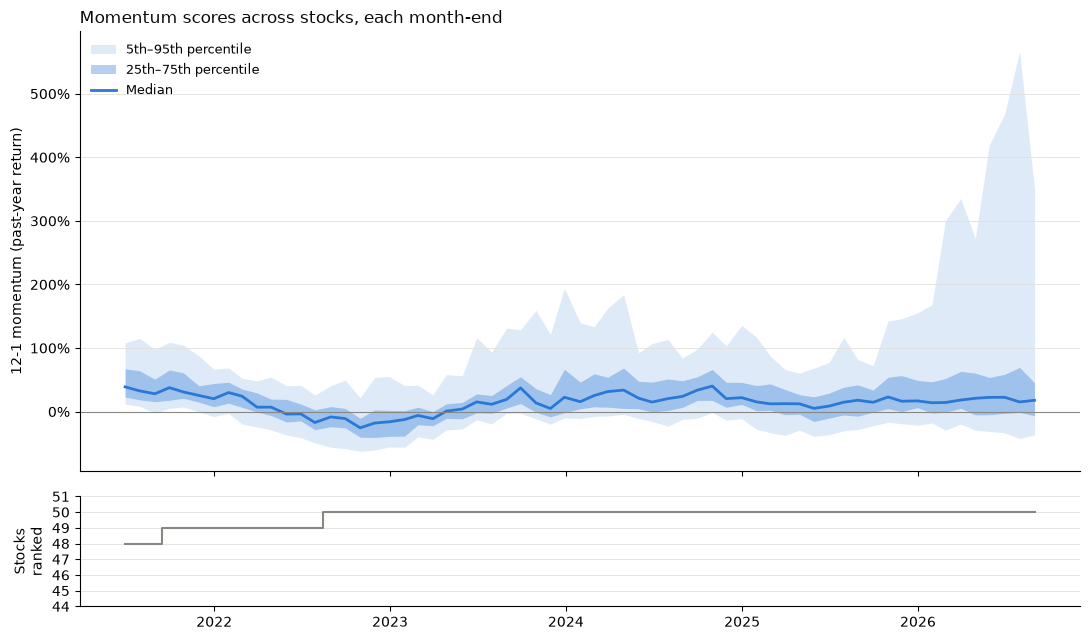

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"
ranked = momentum_signals[momentum_signals["excluded_reason"].isna()]

# --- 1) How the cross-section of momentum scores moves over time ---
q = ranked.groupby("rebalance_date")["mom"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
n = ranked.groupby("rebalance_date").size()

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                              gridspec_kw={"height_ratios": [4, 1]})
ax.fill_between(q.index, q[0.05], q[0.95], color=BLUE, alpha=0.15, lw=0, label="5th–95th percentile")
ax.fill_between(q.index, q[0.25], q[0.75], color=BLUE, alpha=0.35, lw=0, label="25th–75th percentile")
ax.plot(q.index, q[0.5], color=BLUE, lw=2, label="Median")
ax.axhline(0, color=MUTED, lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("12-1 momentum (past-year return)")
ax.set_title("Momentum scores across stocks, each month-end", loc="left", fontsize=12, color=INK)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.grid(axis="y", color=GRID, lw=0.6)
ax2.step(n.index, n.values, where="mid", color=MUTED, lw=1.5)
ax2.set_ylabel("Stocks\nranked")
ax2.set_ylim(44, 51)
ax2.grid(axis="y", color=GRID, lw=0.6)
ax2.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
for a in (ax, ax2):
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("../../reports/momentum_distribution_over_time.png", dpi=150)
plt.show()

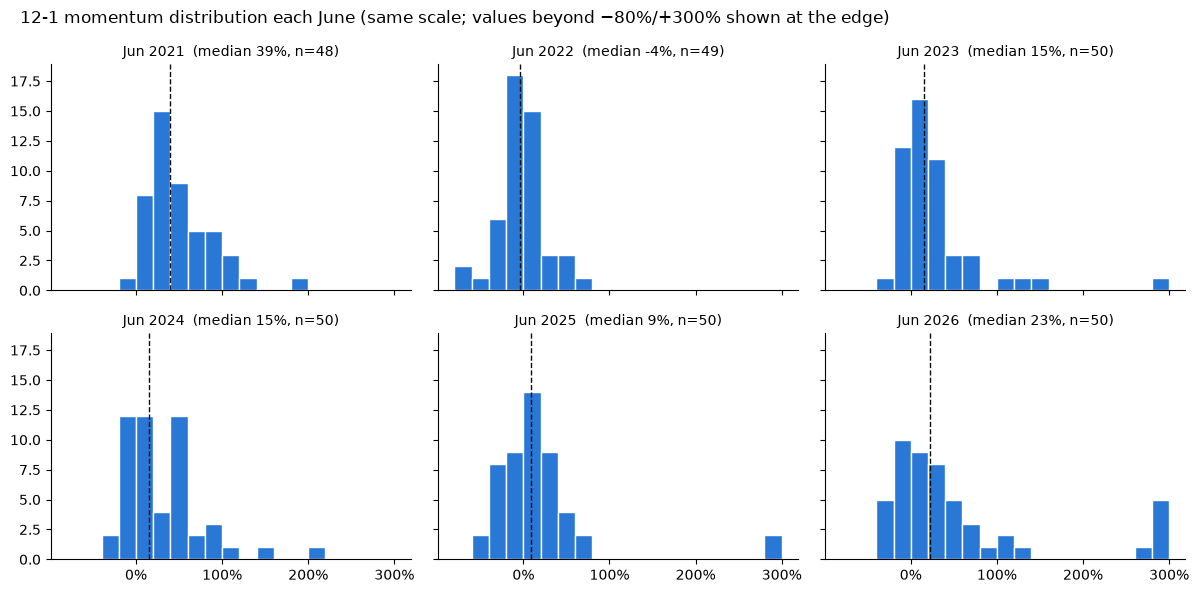

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
BLUE, INK = "#2a78d6", "#0b0b0b"
ranked = momentum_signals[momentum_signals["excluded_reason"].isna()]

# --- 2) Histograms at six dates (one per June) ---
junes = [d for d in sorted(ranked["rebalance_date"].unique()) if pd.Timestamp(d).month == 6]
bins = np.linspace(-0.8, 3.0, 20)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for a, d in zip(axes.flat, junes):
    x = ranked.loc[ranked["rebalance_date"] == d, "mom"]
    a.hist(x.clip(-0.8, 3.0), bins=bins, color=BLUE, edgecolor="white")
    a.axvline(x.median(), color=INK, lw=1, ls="--")
    a.set_title(f"{pd.Timestamp(d):%b %Y}  (median {x.median():.0%}, n={len(x)})", fontsize=10)
    a.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
fig.suptitle("12-1 momentum distribution each June (same scale; values beyond −80%/+300% shown at the edge)", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("../../reports/momentum_histograms_june.png", dpi=150)
plt.show()

### 3.7 Winsorizing check (same test as value)

In [24]:
ranked_m = momentum_signals[momentum_signals["excluded_reason"].isna()]
mom_winsor = ranked_m.groupby("rebalance_date").apply(lambda g: pd.Series({
    "n_ranked":        len(g),
    "p5_cutoff":       g["mom"].quantile(0.05),
    "p95_cutoff":      g["mom"].quantile(0.95),
    "n_capped":        (g["mom"].round(8) != g["mom_w"].round(8)).sum(),
    "median_before":   g["mom"].median(), "median_after": g["mom_w"].median(),
    "max_before":      g["mom"].max(),    "max_after":    g["mom_w"].max(),
    "order_preserved": g.sort_values("mom")["mom_w"].is_monotonic_increasing,
}))
print("order preserved on every date:", mom_winsor["order_preserved"].all())
mom_winsor.iloc[::6].round(3)

order preserved on every date: True


,n_ranked,p5_cutoff,p95_cutoff,n_capped,median_before,median_after,max_before,max_after,order_preserved
rebalance_date,,,,,,,,,
2021-06-30,48,0.119,1.084,6,0.389,0.389,1.895,1.084,True
2021-12-31,49,-0.078,0.668,6,0.203,0.203,1.505,0.668,True
2022-06-30,49,-0.411,0.414,6,-0.036,-0.036,0.742,0.414,True
2022-12-30,50,-0.556,0.553,6,-0.160,-0.160,1.053,0.553,True
2023-06-30,50,-0.127,1.165,6,0.153,0.153,4.550,1.165,True
2023-12-29,50,-0.098,1.941,6,0.225,0.225,2.331,1.941,True
2024-06-28,50,-0.155,1.071,6,0.150,0.150,2.147,1.071,True
2024-12-31,50,-0.113,1.355,6,0.220,0.220,3.933,1.355,True
2025-06-30,50,-0.365,0.772,6,0.086,0.086,4.581,0.772,True


### 3.8 Direction check: biggest past winners and losers

In [25]:
for d in ["2021-12-31", "2022-12-30", "2023-12-29", "2024-12-31", "2025-12-31", "2026-08-31"]:
    g = ranked_m[ranked_m["rebalance_date"] == d].sort_values("mom")
    fmt = lambda x: [f"{r.ticker} {r.mom:+.0%}" for r in x.itertuples()]
    print(d, "| losers:", fmt(g.head(3)), "| winners:", fmt(g.tail(3)))

2021-12-31 | losers: ['PLTR -12%', 'MA -11%', 'V -11%'] | winners: ['STX +69%', 'AMD +73%', 'NVDA +150%']
2022-12-30 | losers: ['RKLB -66%', 'META -65%', 'PLTR -59%'] | winners: ['CVX +62%', 'XOM +89%', 'SMCI +105%']
2023-12-29 | losers: ['PFE -38%', 'CVX -17%', 'TMO -10%'] | winners: ['PLTR +212%', 'NVDA +220%', 'SMCI +233%']
2024-12-31 | losers: ['INTC -51%', 'NKE -27%', 'ADBE -14%'] | winners: ['NVDA +179%', 'PLTR +291%', 'RKLB +393%']
2025-12-31 | losers: ['UNH -34%', 'CRM -31%', 'ADBE -28%'] | winners: ['MU +182%', 'STX +226%', 'WDC +263%']
2026-08-31 | losers: ['NKE -45%', 'ORCL -42%', 'NFLX -41%'] | winners: ['STX +416%', 'WDC +580%', 'MU +593%']


### 3.9 Momentum signal: notes

- **Score:** 12-1 momentum = adj_close(end of month t−1) ÷ adj_close(end of month t−12) − 1, i.e. the 11 monthly returns t−11 … t−1. Month t is skipped to avoid short-term reversal (Jegadeesh & Titman, 1993). `adj_close` is used because momentum is a total return (splits and dividends included).
- **Ranking dates:** every month-end (last trading day) from June 2021 to August 2026, 63 dates. `rank_pct` runs from near 0 (biggest past loser) to 1 (biggest past winner).
- **Timing verified:** on every row the look-back starts in month t−12 and ends in month t−1; `momentum_signal` also asserts this and refuses to run if it is violated.
- **Manual verification:** for NVDA, JNJ, XOM, PLTR and INTC at t = 2023-06-30, the coded value matches both (1) the ratio of the two daily prices and (2) the compounded 11 monthly returns, to 10 decimal places.
- **Exclusions (flagged, not ranked):** stocks without 12 months of history: PLTR until Sep 2021 (listed Sep 2020) and RKLB until Aug 2022 (its earlier prices are the SPAC Vector Acquisition, dropped via `LISTING_DATES`). 48–50 stocks ranked per date. Banks and foreign stocks are *included* (momentum only needs prices).
- **Distribution:** the median moves with the market (about −25% at the 2022 low, +15–40% otherwise); dispersion widened sharply in 2026 as memory and storage stocks (MU, WDC, STX) returned +400–600%. Stable coverage and no gaps or jumps unexplained by the market.
- **Winsorizing:** 5th/95th percentile within each date; 6 stocks capped per date; order preserved on every date.
- **Limitations:** 50 hand-picked large caps; extreme 2026 winners are concentrated in one industry, so momentum portfolios then are partly an industry bet.